In [29]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kurtosis, skew
from statsmodels.tsa.stattools import adfuller
from datetime import datetime
from statsmodels.graphics.tsaplots import plot_acf
from scipy.fft import fft, fftfreq

def get_date_key(filename):
    name = os.path.basename(filename).replace('.txt', '')
    return datetime.strptime(name, "%d%m%Y")

# Find files
raw_files = glob.glob('*.txt')

# Sort data files
# Ensures Oct 29 (2910...) comes before Nov 01 (0111...)
all_files = sorted(raw_files, key=get_date_key)

# Define column names from the documentation 
column_names = [
    "time_stamp", "p1_juice_inlet", "p2_juice_outlet", "t_juice_outlet", 
    "f_juice_flow_evap1_in", "lc51_03cv", "lc51_03x", "lc51_03pv", 
    "t_juice_evap1_in", "t_juice_evap1_out", "d_juice_evap1_in", "d_juice_evap1_out", 
    "steam_flow", "steam_pressure", "steam_temp", "vapour_pressure", 
    "vapour_temp", "p1_juice_inlet_act2", "p2_juice_outlet_act2", "t_juice_inlet_act2", 
    "fc57_03pv", "fc57_03cv", "fc57_03x", "p1_water_inlet_act3", 
    "p2_water_outlet_act3", "t_water_outlet_act3", "f_water_flow_boiler_in", "lc74_20cv", 
    "lc74_20x", "lc74_20pv", "f_steam_boiler_out", "p_steam_boiler_out", "t_steam_boiler_out"
]

for f in all_files:
    print(f" -> {f}")

# ignore_index=True automatically creates a continuous index
df = pd.concat((pd.read_csv(f, sep='\t', header=None) for f in all_files), ignore_index=True)
df.columns = column_names

# Create a specific column for the continuous timeline
df['Cumulative_Time'] = df.index 
df = df.drop(columns=['time_stamp'])

output_filename = "merged_data.txt"

# Save the DataFrame to a .txt file
# index=False prevents pandas from adding an extra column for the row numbers
df.to_csv(output_filename, sep='\t', index=False)

 -> 29102001.txt
 -> 30102001.txt
 -> 31102001.txt
 -> 01112001.txt
 -> 02112001.txt
 -> 03112001.txt
 -> 04112001.txt
 -> 05112001.txt
 -> 06112001.txt
 -> 07112001.txt
 -> 08112001.txt
 -> 09112001.txt
 -> 10112001.txt
 -> 11112001.txt
 -> 12112001.txt
 -> 13112001.txt
 -> 14112001.txt
 -> 15112001.txt
 -> 16112001.txt
 -> 17112001.txt
 -> 18112001.txt
 -> 19112001.txt
 -> 20112001.txt
 -> 21112001.txt
 -> 22112001.txt


In [2]:
# load merged data
df = pd.read_csv("merged_data.txt", sep="\t")
print(df.shape)

df.head()

(2160000, 33)


,p1_juice_inlet,p2_juice_outlet,t_juice_outlet,f_juice_flow_evap1_in,lc51_03cv,lc51_03x,lc51_03pv,t_juice_evap1_in,t_juice_evap1_out,d_juice_evap1_in,...,p2_water_outlet_act3,t_water_outlet_act3,f_water_flow_boiler_in,lc74_20cv,lc74_20x,lc74_20pv,f_steam_boiler_out,p_steam_boiler_out,t_steam_boiler_out,Cumulative_Time
0,693.8,306.0,97.3,310.5,37.9,39.9,50.2,128.3,133.6,13.3,...,2596.3,101.7,13.6,57.4,65.4,51.3,13.8,2456.7,388.4,0
1,687.9,310.4,97.3,318.4,36.3,37.1,49.5,128.3,133.6,13.3,...,2608.1,101.8,12.3,61.7,67.3,49.6,13.9,2456.7,388.6,1
2,676.4,319.7,97.3,324.3,35.2,37.2,49.0,128.3,133.7,13.3,...,2619.8,101.8,15.9,54.7,63.8,51.0,14.0,2456.7,388.6,2
3,668.4,327.7,97.3,331.7,34.5,37.0,48.9,128.3,133.7,13.3,...,2633.5,101.8,20.8,57.2,58.3,51.0,14.0,2456.7,388.4,3
4,659.1,327.2,97.4,340.0,34.2,35.6,48.7,128.4,133.7,13.3,...,2582.7,101.8,23.4,60.9,55.6,49.9,13.8,2456.7,388.4,4


In [3]:
sensors = df.drop(columns=["Cumulative_Time"])
time = df["Cumulative_Time"]
print(sensors.shape)   # should be (2160000, 32)

(2160000, 32)


In [4]:
# check data types
sensors.dtypes.unique()

array([dtype('float64')], dtype=object)

In [5]:
# check for missing values
int(sensors.isna().sum().sum())

0

In [6]:
# basic statistics
stats_describe = sensors.describe().T
stats_describe.head()

,count,mean,std,min,25%,50%,75%,max
p1_juice_inlet,2160000.0,645.304637,37.223172,381.7,628.3,646.9,665.7,812.9
p2_juice_outlet,2160000.0,353.391190,25.702490,0.7,338.0,354.6,370.0,445.2
t_juice_outlet,2160000.0,96.569562,1.245168,69.6,96.0,96.7,97.3,99.5
f_juice_flow_evap1_in,2160000.0,357.363384,21.047729,198.5,346.8,359.8,371.2,437.2
lc51_03cv,2160000.0,34.866097,4.461385,0.1,32.8,34.6,36.4,100.0


In [7]:
# denoising
USE_SMOOTH_FOR_PLOTS = True
ROLL_WINDOW = 5

if USE_SMOOTH_FOR_PLOTS:
    sensors_smooth = sensors.rolling(window=ROLL_WINDOW).mean().bfill()
else:
    sensors_smooth = None

In [8]:
# EDA metrics table
stats = pd.DataFrame(index=sensors.columns)

stats["mean"] = sensors.mean()
stats["std"] = sensors.std()
stats["stability_score"] = (stats["mean"] / stats["std"]).abs()
stats["kurtosis"] = sensors.apply(kurtosis)
stats["skew"] = sensors.apply(skew)

# Drift magnitude (end vs start mean)
window = int(len(sensors) * 0.05)
stats["drift_magnitude"] = (sensors.tail(window).mean() - sensors.head(window).mean()).abs()

display(stats.sort_values("std", ascending=False).head(10))

,mean,std,stability_score,kurtosis,skew,drift_magnitude
p1_water_inlet_act3,3309.376899,920.375623,3.595681,8.030046,-3.136820,13.663356
p2_water_outlet_act3,2420.099397,671.967253,3.601514,8.081597,-3.145935,31.370551
p_steam_boiler_out,2255.084936,574.573454,3.924798,8.889472,-3.253676,31.090202
t_steam_boiler_out,375.009767,70.206608,5.341517,7.778920,-3.062422,14.044208
p1_juice_inlet,645.304637,37.223172,17.336100,6.108233,-1.121196,22.456017
p2_juice_outlet,353.391190,25.702490,13.749298,10.786389,-1.161145,44.289150
f_juice_flow_evap1_in,357.363384,21.047729,16.978715,3.836348,-1.258219,19.919477
lc74_20cv,60.744006,16.207152,3.747975,6.666852,-1.758258,0.665114
p1_juice_inlet_act2,501.405246,15.979218,31.378584,130.394784,-4.037746,13.469435
lc74_20x,62.654239,15.910997,3.937795,7.864634,-2.100324,0.999062


In [9]:
# rankings
print("\nTOP 10 MOST ACTIVE (High Std)")
print(stats.sort_values(by="std", ascending=False).head(10))

print("\nTOP 10 SPIKIEST (High Kurtosis)")
print(stats.sort_values(by="kurtosis", ascending=False).head(10))

print("\nTOP 10 DRIFTING (High Drift)")
print(stats.sort_values(by="drift_magnitude", ascending=False).head(10))

print("\nTOP 10 MOST STABLE (High Stability Score)")
print(stats.sort_values(by="stability_score", ascending=False).head(10))



TOP 10 MOST ACTIVE (High Std)
                              mean         std  stability_score    kurtosis  \
p1_water_inlet_act3    3309.376899  920.375623         3.595681    8.030046   
p2_water_outlet_act3   2420.099397  671.967253         3.601514    8.081597   
p_steam_boiler_out     2255.084936  574.573454         3.924798    8.889472   
t_steam_boiler_out      375.009767   70.206608         5.341517    7.778920   
p1_juice_inlet          645.304637   37.223172        17.336100    6.108233   
p2_juice_outlet         353.391190   25.702490        13.749298   10.786389   
f_juice_flow_evap1_in   357.363384   21.047729        16.978715    3.836348   
lc74_20cv                60.744006   16.207152         3.747975    6.666852   
p1_juice_inlet_act2     501.405246   15.979218        31.378584  130.394784   
lc74_20x                 62.654239   15.910997         3.937795    7.864634   

                           skew  drift_magnitude  
p1_water_inlet_act3   -3.136820        13.663356

In [16]:
# candidate signals
top_var = list(stats["std"].sort_values(ascending=False).head(5).index)
top_kurt = list(stats["kurtosis"].sort_values(ascending=False).head(5).index)
candidate_signals = list(dict.fromkeys(top_var + top_kurt))  # preserve order, remove duplicates

print("\nCandidate signals:", candidate_signals)


Candidate signals: ['p1_water_inlet_act3', 'p2_water_outlet_act3', 'p_steam_boiler_out', 't_steam_boiler_out', 'p1_juice_inlet', 'p1_juice_inlet_act2', 't_juice_outlet', 'lc51_03pv', 'steam_temp', 'lc74_20pv']


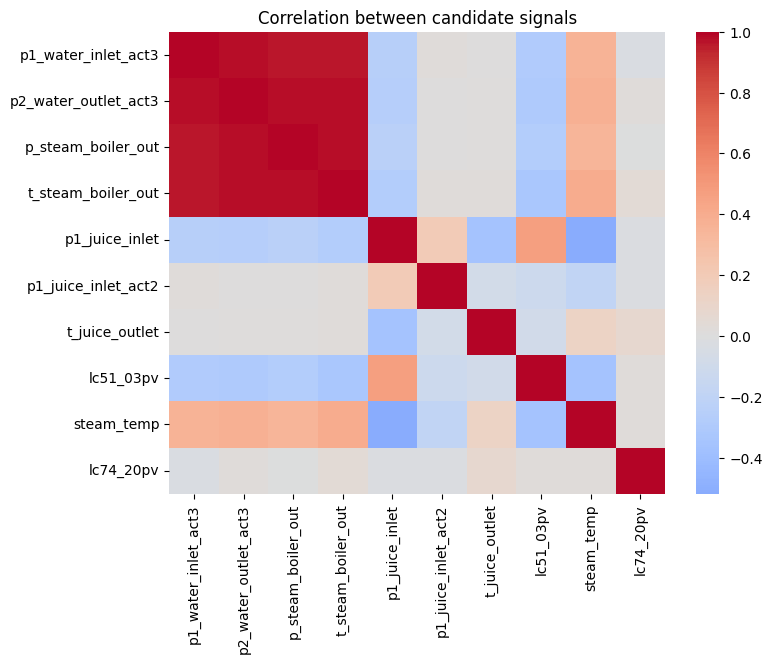

In [17]:
# correlation heatmap
corr = sensors[candidate_signals].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation between candidate signals")
plt.show()

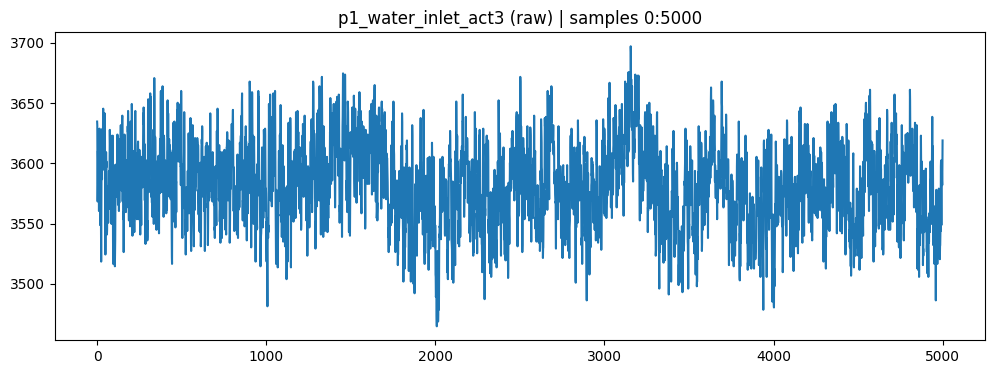

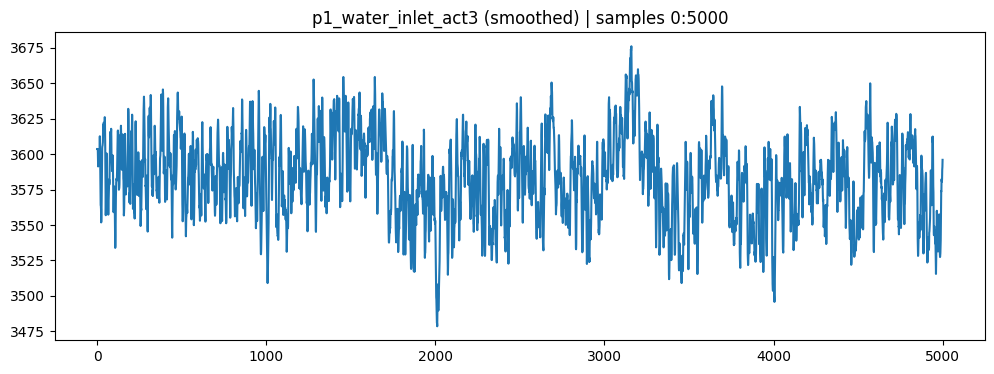

In [18]:
# visualize signals

sig = candidate_signals[0]
start, end = 0, 5000

plt.figure(figsize=(12,4))
plt.plot(sensors[sig].iloc[start:end])
plt.title(f"{sig} (raw) | samples {start}:{end}")
plt.show()

if USE_SMOOTH_FOR_PLOTS:
    plt.figure(figsize=(12,4))
    plt.plot(sensors_smooth[sig].iloc[start:end])
    plt.title(f"{sig} (smoothed) | samples {start}:{end}")
    plt.show()

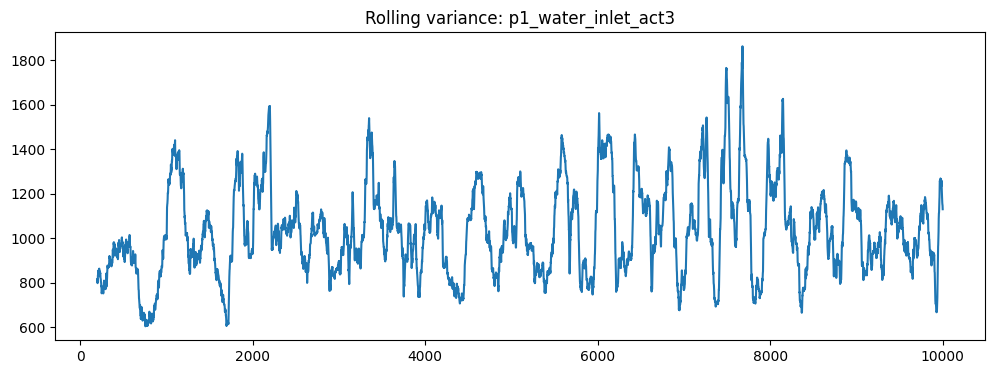

In [19]:
# rolling variance (local instability)
rolling_var = sensors[sig].rolling(200).var()

plt.figure(figsize=(12,4))
plt.plot(rolling_var.iloc[0:10000])
plt.title(f"Rolling variance: {sig}")
plt.show()

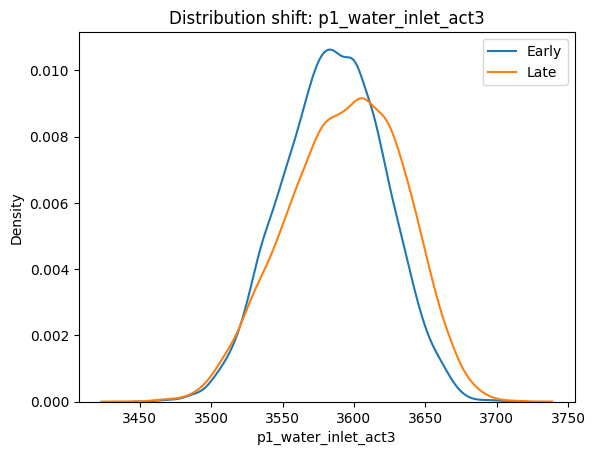

In [20]:
# distribution shift visualization
early = sensors[sig].iloc[:10000]
late = sensors[sig].iloc[-10000:]

sns.kdeplot(early, label="Early")
sns.kdeplot(late, label="Late")
plt.legend()
plt.title(f"Distribution shift: {sig}")
plt.show()

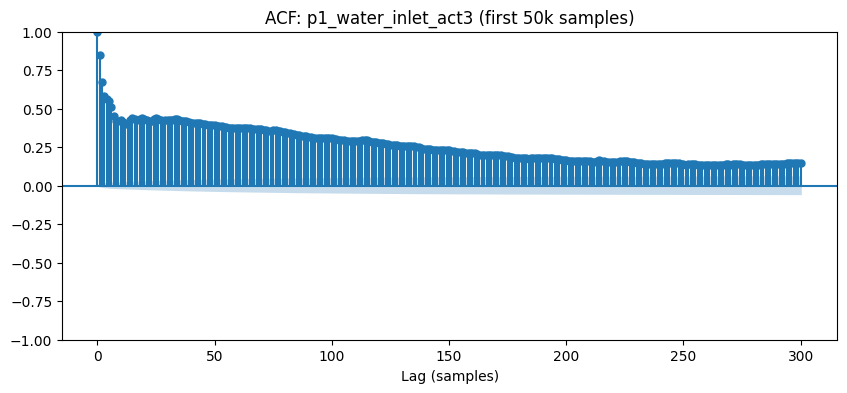

In [26]:
# Autocorrelation (ACF)
    # ACF on a subset
series_for_acf = sensors[sig].iloc[:50000]
fig, ax = plt.subplots(figsize=(10,4))
plot_acf(series_for_acf, lags=300, ax=ax)
ax.set_title(f"ACF: {sig} (first 50k samples)")
ax.set_xlabel("Lag (samples)")
plt.show()

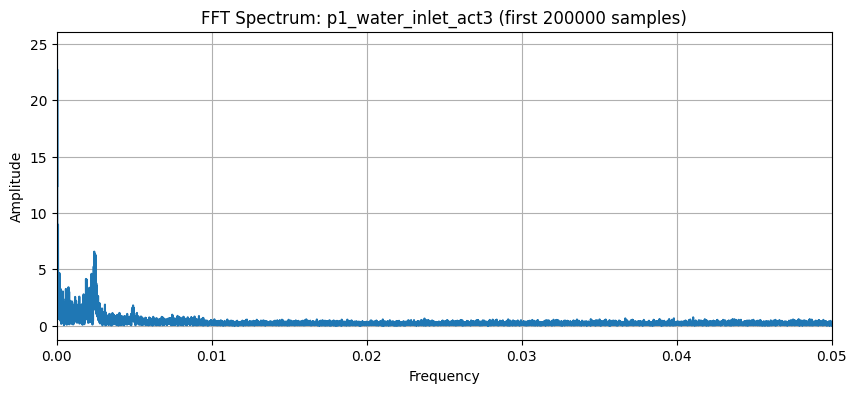

In [30]:
# FFT / frequency spectrum

fft_n = 200000  # use subset for speed
y = sensors[sig].iloc[:fft_n].values
y = y - np.mean(y)

N = len(y)
yf = fft(y)
xf = fftfreq(N, 1.0)[:N//2]

plt.figure(figsize=(10,4))
plt.plot(xf, 2.0/N * np.abs(yf[:N//2]))
plt.xlim(0, 0.05)
plt.title(f"FFT Spectrum: {sig} (first {fft_n} samples)")
plt.xlabel("Frequency")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

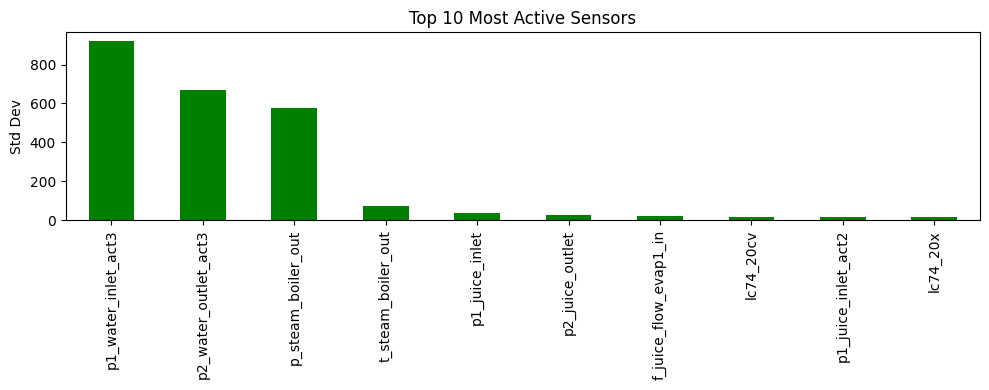

In [32]:
# top 10 most active sensors bar chart
plt.figure(figsize=(10,4))
stats["std"].sort_values(ascending=False).head(10).plot(kind="bar", color='green')
plt.title("Top 10 Most Active Sensors")
plt.ylabel("Std Dev")
plt.tight_layout()
plt.show()